Dataset size: 5572
                                        processed_v2 label
0  Go until jurong point, crazy.. Available only ...   ham
1                      Ok lar... Joking wif u oni...   ham
2  Free entry in 2 a wkly comp to win FA Cup fina...  spam
3  U dun say so early hor... U c already then say...   ham
4  Nah I don't think he goes to usf, he lives aro...   ham

Split sizes
Train: 3900
Val: 836
Test: 836

Class distribution (train)
label
ham     3377
spam     523
Name: count, dtype: int64

=== Logistic Regression Baseline ===
Accuracy: 0.9617224880382775
Macro-F1: 0.9058558558558558
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       724
        spam       1.00      0.71      0.83       112

    accuracy                           0.96       836
   macro avg       0.98      0.86      0.91       836
weighted avg       0.96      0.96      0.96       836


=== Linear SVM (word ngrams) ===
Accuracy: 0.9856459330143541
Macro-F1: 0

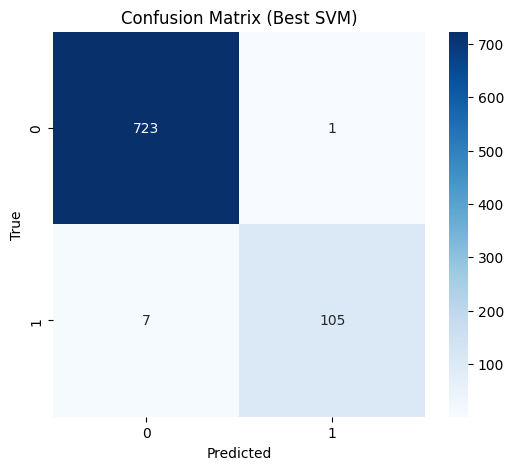

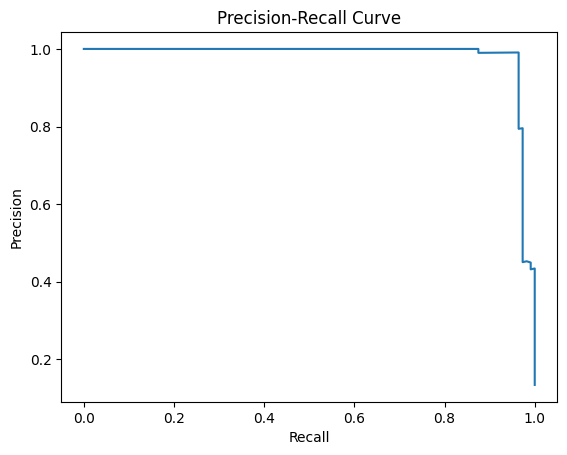


Threshold evaluation
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       724
           1       0.99      0.94      0.96       112

    accuracy                           0.99       836
   macro avg       0.99      0.97      0.98       836
weighted avg       0.99      0.99      0.99       836


ERROR ANALYSIS (10 examples)
                                           processed_v2 label  pred
2352  Download as many ringtones as u like no restri...  spam   ham
2247  Hi ya babe x u 4goten bout me?' scammers getti...  spam   ham
3460  Not heard from U4 a while. Call me now am here...  spam   ham
700            K..u also dont msg or reply to his msg..   ham  spam
3981                                 ringtoneking 84484  spam   ham
731   Email AlertFrom: Jeri StewartSize: 2KBSubject:...  spam   ham
3530  Xmas & New Years Eve tickets are now on sale f...  spam   ham
2823  ROMCAPspam Everyone around should be respondin...  spam   ham

=== FINA

In [2]:
# =========================
# 1. INSTALL
# =========================
!pip install pandas scikit-learn matplotlib seaborn

# =========================
# 2. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

# =========================
# 3. LOAD DATA (той самий dataset як у ЛР6)
# =========================
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", header=None, names=["label", "text"])

df["processed_v2"] = df["text"]

TEXT_COL = "processed_v2"
LABEL_COL = "label"

df = df[[TEXT_COL, LABEL_COL]].dropna()

print("Dataset size:", len(df))
print(df.head())

# =========================
# 4. TRAIN / VAL / TEST SPLIT
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df[LABEL_COL]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df[LABEL_COL]
)

print("\nSplit sizes")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nClass distribution (train)")
print(train_df[LABEL_COL].value_counts())

# =========================
# 5. BASELINE (Lab6)
# TF-IDF word(1,2) + Logistic Regression
# =========================
baseline_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(max_iter=300))
])

baseline_logreg.fit(train_df[TEXT_COL], train_df[LABEL_COL])

pred_logreg = baseline_logreg.predict(val_df[TEXT_COL])

acc_log = accuracy_score(val_df[LABEL_COL], pred_logreg)
f1_log = f1_score(val_df[LABEL_COL], pred_logreg, average="macro")

print("\n=== Logistic Regression Baseline ===")
print("Accuracy:", acc_log)
print("Macro-F1:", f1_log)
print(classification_report(val_df[LABEL_COL], pred_logreg))

# =========================
# 6. Linear SVM (word ngrams)
# =========================
svm_word = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2),
        sublinear_tf=True
    )),
    ("clf", LinearSVC(C=1.0))
])

svm_word.fit(train_df[TEXT_COL], train_df[LABEL_COL])

pred_svm = svm_word.predict(val_df[TEXT_COL])

acc_svm = accuracy_score(val_df[LABEL_COL], pred_svm)
f1_svm = f1_score(val_df[LABEL_COL], pred_svm, average="macro")

print("\n=== Linear SVM (word ngrams) ===")
print("Accuracy:", acc_svm)
print("Macro-F1:", f1_svm)
print(classification_report(val_df[LABEL_COL], pred_svm))

# =========================
# 7. SVM + CHAR NGRAMS
# =========================
svm_char = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3,5)
    )),
    ("clf", LinearSVC())
])

svm_char.fit(train_df[TEXT_COL], train_df[LABEL_COL])

pred_char = svm_char.predict(val_df[TEXT_COL])

acc_char = accuracy_score(val_df[LABEL_COL], pred_char)
f1_char = f1_score(val_df[LABEL_COL], pred_char, average="macro")

print("\n=== Linear SVM (char ngrams) ===")
print("Accuracy:", acc_char)
print("Macro-F1:", f1_char)
print(classification_report(val_df[LABEL_COL], pred_char))

# =========================
# 8. SVM WITH class_weight="balanced"
# =========================
svm_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1,2)
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

svm_balanced.fit(train_df[TEXT_COL], train_df[LABEL_COL])

pred_bal = svm_balanced.predict(val_df[TEXT_COL])

acc_bal = accuracy_score(val_df[LABEL_COL], pred_bal)
f1_bal = f1_score(val_df[LABEL_COL], pred_bal, average="macro")

print("\n=== Linear SVM (balanced) ===")
print("Accuracy:", acc_bal)
print("Macro-F1:", f1_bal)
print(classification_report(val_df[LABEL_COL], pred_bal))

# =========================
# 9. MODEL COMPARISON TABLE
# =========================
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM word",
        "Linear SVM char",
        "Linear SVM balanced"
    ],
    "Accuracy":[acc_log, acc_svm, acc_char, acc_bal],
    "Macro-F1":[f1_log, f1_svm, f1_char, f1_bal]
})

print("\nMODEL COMPARISON")
print(results)

# =========================
# 10. CONFUSION MATRIX
# =========================
cm = confusion_matrix(val_df[LABEL_COL], pred_bal)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Best SVM)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# =========================
# 11. PR CURVE
# =========================
scores = svm_balanced.decision_function(val_df[TEXT_COL])

y_binary = (val_df[LABEL_COL] == "spam").astype(int)

precision, recall, thresholds = precision_recall_curve(y_binary, scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# =========================
# 12. THRESHOLD EXPERIMENT
# =========================
threshold = 0.0

custom_pred = (scores > threshold).astype(int)

print("\nThreshold evaluation")
print(classification_report(y_binary, custom_pred))

# =========================
# 13. ERROR ANALYSIS
# =========================
errors = val_df.copy()

errors["pred"] = pred_bal

errors = errors[errors[LABEL_COL] != errors["pred"]]

print("\nERROR ANALYSIS (10 examples)")
print(errors.head(10))

# =========================
# 14. FINAL TEST EVALUATION
# =========================
test_pred = svm_balanced.predict(test_df[TEXT_COL])

print("\n=== FINAL TEST RESULTS ===")
print("Accuracy:", accuracy_score(test_df[LABEL_COL], test_pred))
print("Macro-F1:", f1_score(test_df[LABEL_COL], test_pred, average="macro"))
print(classification_report(test_df[LABEL_COL], test_pred))